In [ ]:
from google.colab import files
uploaded = files.upload()
print(uploaded)

Saving data.xlsx to data.xlsx
{'data.xlsx': b'PK\x03\x04\x14\x00\x08\x08\x08\x00\xbc-\xecZ\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x18\x00\x00\x00xl/drawings/drawing1.xml\x9d\xd0]n\xc20\x0c\x07\xf0\x13\xec\x0eU\xdeiZ\x18\x13C\x14^\xd0N0\x0e\xe0%n\x1b\x91\x8f\xca\x0e\xa3\xdc~\xd1J6i{\x01\x1em\xcb?\xf9\xef\xcdnt\xb6\xf8Db\x13|#\xea\xb2\x12\x05z\x15\xb4\xf1]#\x0e\xefo\xb3\x95(8\x82\xd7`\x83\xc7F\\\x90\xc5n\xfb\xb4\x195\xad\xcf\xbc\xa7"\xed{^\xa7\xb2\x11}\x8c\xc3ZJV=:\xe02\x0c\xe8\xd3\xb4\r\xe4 \xa6\x92:\xa9\t\xceIvV\xce\xab\xeaE\xf2@\x08\x9a{\xc4\xb8\x9f&\xe2\xea\xc1\x03\x9a\x03\xe3\xf3\xfeM\xd7\x84\xb65\n\xf7A\x9d\x1c\xfa8!\x84\x16b\xfa\x05\xf7f\xe0\xac\xa9\x07\xaeQ=P\xfc\x01\xc6\x7f\x823\x8a\x02\x876\x96*\xb8\xeb)\xd9HB\xfd<\t8\xfe\x1a\xf5\xdd\xc8R\xbe\xca\xd5_\xc8\xdd\x14\xc7\x01\x1dO\xc3,\xb9Cz\xc8\x87\xb1&^\xbe\x93eFw\xee\x81\xb7h\x03\x1d\x81\xcb\xc8\xb88\xf8\xe3\xdd\xb1*\xc96\xb5(+l\xb1^\xde\xad\xcc\xb3"\xb7_PK\x07\x08\x07bi\x83\x05\x01\x00\x00\x07\x03\x00\x00PK\x03\x04\x14\

In [ ]:
import pandas as pd
import io
df = pd.read_excel(io.BytesIO(uploaded['data.xlsx']))
print(df)

      Loan_ID  Gender Married Dependents       Education Self_Employed  \
0    LP002139    mAle     Yes          0        Graduate            No   
1    LP002223    Mail     Yes          0        gRaDuate            No   
2    LP001570    mAle     Yes          2        graduate            No   
3    LP002978  Femala      No          0        gRaDuate            No   
4    LP001478    mAle      No          0        gRaDuate            No   
..        ...     ...     ...        ...             ...           ...   
614  LP002821    Male      No          0  Not   Graduate           Yes   
615  LP002789    Mail     Yes          0        graduate            No   
616  LP002272    Male     Yes          2        gRaDuate            No   
617  LP001245    mAle     Yes          2          Senior           Yes   
618  LP001935    mAle      No          0        graduate            No   

     Applicant Income  Co applicant Income  Loan Amount  Loan_Amount_Term  \
0                9083             

In [ ]:
#cleainig gender column
# Standardize gender values
df['Gender'] = df['Gender'].str.lower().replace({
    'male': 'Male',
    'mail': 'Male',
    'males': 'Male',
    'female': 'Female',
    'femala': 'Female'
})

In [ ]:
#cleaining education column
# Standardize education values
df['Education'] = df['Education'].str.lower().str.strip().replace({
    'graduate': 'Graduate',
    'not graduate': 'Not Graduate',
    'senior': 'Not Graduate'  # Assuming 'Senior' means not graduated
})

In [ ]:
print(df['Gender'].value_counts())
print(df['Education'].value_counts())

Gender
Male      494
Female     83
girl       29
Name: count, dtype: int64
Education
Graduate          483
#junior            40
freshman           37
Not Graduate       32
not   graduate     27
Name: count, dtype: int64


In [ ]:
#How many of the customers who applied for a loan are graduates?
df['Education'] = df['Education'].str.lower().str.strip()
education_counts = df['Education'].value_counts()
print("Number of Graduates vs. Non-Graduates:")
print(education_counts)

Number of Graduates vs. Non-Graduates:
Education
graduate          483
#junior            40
freshman           37
not graduate       32
not   graduate     27
Name: count, dtype: int64


In [ ]:
#Does the marital Status affect the LoanAmount?
df['Married'] = df['Married'].str.lower().str.strip()
loan_by_marital = df.groupby('Married')['Loan Amount'].describe()
print(loan_by_marital)

         count          mean            std   min     25%    50%     75%  \
Married                                                                    
no       208.0  48487.447115  286559.050189   9.0   92.25  119.0  151.25   
yes      388.0  34103.783505  227630.240270  17.0  108.00  133.0  181.25   

               max  
Married             
no       1996433.0  
yes      1972992.0  


In [ ]:
# Is Self Employment related to Credit History?
df['Self_Employed'] = df['Self_Employed'].str.lower().str.strip()
df['Credit_History'] = df['Credit_History'].astype(float) #Ensure numeric (1.0 = good, 0.0 = bad, NaN = missing)
ct = pd.crosstab(df['Self_Employed'], df['Credit_History'], margins=True)
print(ct)

Credit_History  0.0  1.0  All
Self_Employed                
no               77  388  465
yes              12   65   77
All              89  453  542


In [ ]:
#Does the applicant Income have any relation to the Gender and Education?
df['Gender'] = df['Gender'].str.lower().str.strip()
df['Education'] = df['Education'].str.lower().str.strip()
df_clean = df.dropna(subset=['Applicant Income', 'Gender', 'Education'])
income_stats = df_clean.groupby(['Gender', 'Education'])['Applicant Income'].describe()
print(income_stats[['count', 'mean', 'std']])

                       count         mean           std
Gender Education                                       
femala #junior           1.0  2149.000000           NaN
       freshman          3.0  3310.000000   1172.339115
       graduate         26.0  4245.692308   2309.868997
       not   graduate    3.0  3921.333333   1570.605722
female #junior           4.0  3677.250000   2364.253423
       freshman          3.0  8226.000000   8712.573730
       graduate         41.0  5506.682927   4423.971815
       senior            2.0  9595.500000  10843.482489
girl   #junior           2.0  1805.000000   2255.670632
       freshman          1.0  4350.000000           NaN
       graduate         25.0  3652.520000   1040.595908
       not   graduate    1.0  2213.000000           NaN
mail   #junior          12.0  3268.916667   1245.239258
       freshman         13.0  3762.153846   1639.570617
       graduate        127.0  6650.000000   8526.323793
       not   graduate    5.0  3464.400000   1792

In [ ]:
#Does the applicant Income have any relation to the Loan Status?
loan_status_income = df_clean.groupby('Loan_Status')['Applicant Income'].describe()
print(loan_status_income[['count', 'mean', 'std']])
from scipy.stats import mannwhitneyu

approved = df_clean[df_clean['Loan_Status'] == 'Y']['Applicant Income']
rejected = df_clean[df_clean['Loan_Status'] == 'N']['Applicant Income']

stat, p_value = mannwhitneyu(approved, rejected, alternative='greater')
print(f"P-value: {p_value:.4f}")

             count         mean          std
Loan_Status                                 
N            188.0  5499.250000  6882.044200
Y            418.0  5199.954545  5211.762381
P-value: 0.6668


In [ ]:
#How many of the applicants have a Loan Status (“yes”) where who are “Not Graduates”
df['Education'] = df['Education'].str.lower().str.strip()
df['Loan_Status'] = df['Loan_Status'].str.upper().str.strip()
not_graduates_approved = df[(df['Education'] == 'not graduate') & (df['Loan_Status'] == 'Y')]
count = len(not_graduates_approved)
print(f"Number of approved non-graduate applicants: {count}")

Number of approved non-graduate applicants: 0


In [ ]:
# Convert Credit_History to numeric (1.0 = good, 0.0 = bad, NaN = missing)
df['Credit_History'] = pd.to_numeric(df['Credit_History'], errors='coerce')
df['Loan_Status'] = df['Loan_Status'].str.upper().str.strip()  # Ensure "Y" or "N"
ct = pd.crosstab(df['Credit_History'], df['Loan_Status'], margins=True)
print(ct)
from scipy.stats import chi2_contingency
chi2, p_value, _, _ = chi2_contingency(pd.crosstab(df['Credit_History'].dropna(), df['Loan_Status']))
print(f"P-value: {p_value:.4f}")

Loan_Status       N    Y  All
Credit_History               
0.0              83    7   90
1.0              97  381  478
All             180  388  568
P-value: 0.0000


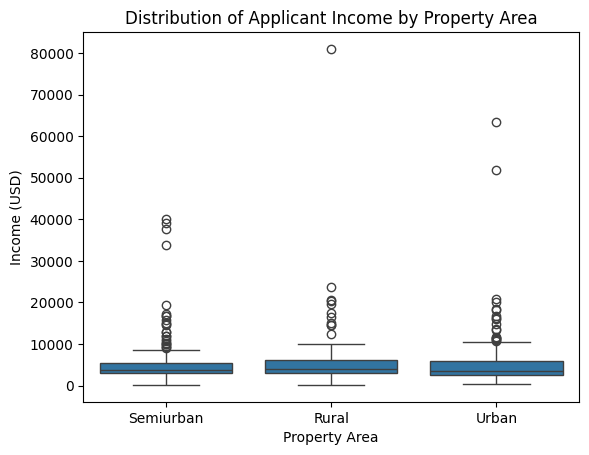

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create the boxplot
sns.boxplot(
    x='Property_Area',  # Categorical variable (Urban, Rural, Semiurban)
    y='Applicant Income', # Numerical variable
    data=df
)

# Add titles and labels
plt.title("Distribution of Applicant Income by Property Area")
plt.xlabel("Property Area")
plt.ylabel("Income (USD)")

plt.show()

In [ ]:
#Tidy up the column names, make sure there are no spaces
df.columns = df.columns.str.replace(' ', '')
print(df.columns.tolist())

['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']


In [ ]:
# Identify duplicate rows
duplicates = df[df.duplicated(keep=False)]  # keep=False marks all duplicates
print(f"Found {len(duplicates)} duplicate rows")

# Remove duplicates (if needed)
df = df.drop_duplicates()

Found 10 duplicate rows


In [ ]:
# Standardize text columns
text_columns = ['Gender', 'Married', 'Education', 'Property_Area']
for col in text_columns:
    df[col] = df[col].str.upper().str.strip()

/tmp/ipython-input-22-2889468681.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].str.upper().str.strip()


In [ ]:
# Check missing values per column
missing_data = df.isnull().sum()
print("Missing Values:\n", missing_data[missing_data > 0])

Missing Values:
 Gender              13
Married              3
Dependents          15
Self_Employed       32
LoanAmount          21
Loan_Amount_Term    14
Credit_History      50
dtype: int64


In [ ]:
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median())
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

/tmp/ipython-input-26-3817256882.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])
/tmp/ipython-input-26-3817256882.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
/tmp/ipython-input-26-3817256882.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See 

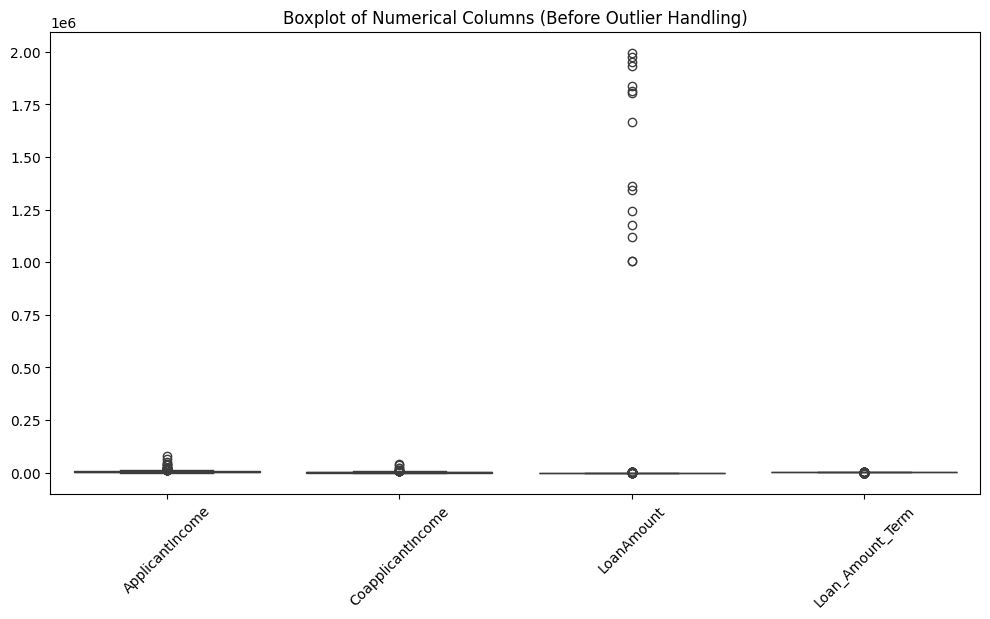

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot boxplots for numerical columns
num_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[num_cols])
plt.xticks(rotation=45)
plt.title("Boxplot of Numerical Columns (Before Outlier Handling)")
plt.show()

In [ ]:
def cap_outliers(df, column, upper_percentile=0.95):
    cap_value = df[column].quantile(upper_percentile)
    df[column] = df[column].clip(upper=cap_value)
    return df

df = cap_outliers(df, 'ApplicantIncome', upper_percentile=0.95)
df = cap_outliers(df, 'LoanAmount', upper_percentile=0.99)

/tmp/ipython-input-28-3506940535.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column] = df[column].clip(upper=cap_value)
/tmp/ipython-input-28-3506940535.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column] = df[column].clip(upper=cap_value)


/tmp/ipython-input-30-1510822890.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Log_Income'] = np.log1p(df['ApplicantIncome'])  # log(1 + x) to avoid log(0)


<Axes: ylabel='Log_Income'>

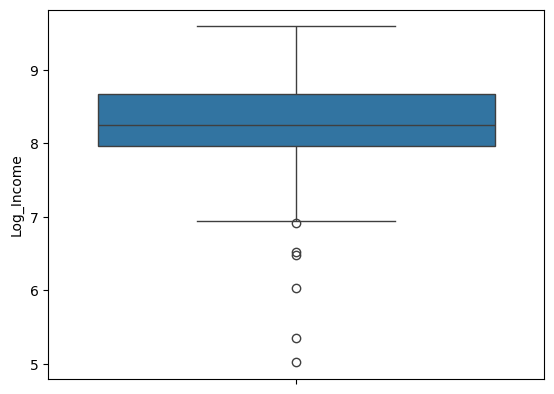

In [ ]:
import numpy as np
df['Log_Income'] = np.log1p(df['ApplicantIncome'])  # log(1 + x) to avoid log(0)
sns.boxplot(df['Log_Income'])

In [ ]:
import pandas as pd

# Perform categorical data transformation
#Categorical Columns have been transformed into multiple binary (yes/no) columns
df_encoded = pd.get_dummies(df, columns=['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status'])

# Print the encoded DataFrame
print(df_encoded)

      Loan_ID Dependents  Applicant Income  Co applicant Income  Loan Amount  \
0    LP002139          0              9083                  0.0        228.0   
1    LP002223          0              4310                  0.0        130.0   
2    LP001570          2              4167               1447.0        158.0   
3    LP002978          0              2900                  0.0         71.0   
4    LP001478          0              2718                  0.0         70.0   
..        ...        ...               ...                  ...          ...   
614  LP002821          0              5800                  0.0        132.0   
615  LP002789          0              3593               4266.0        132.0   
616  LP002272          2              3276                484.0        135.0   
617  LP001245          2              1875               1875.0         97.0   
618  LP001935          0              9508                  0.0        187.0   

     Loan_Amount_Term  Credit_History  

   Applicant Income_minmax  Co applicant Income_minmax  Loan Amount_minmax  \
0                 0.110489                    0.000000            0.000110   
1                 0.051453                    0.000000            0.000061   
2                 0.049685                    0.034728            0.000075   
3                 0.034014                    0.000000            0.000031   
4                 0.031763                    0.000000            0.000031   

   Loan_Amount_Term_minmax  Credit_History_minmax  
0                  0.74359                    1.0  
1                  0.74359                    NaN  
2                  0.74359                    1.0  
3                  0.74359                    1.0  
4                  0.74359                    1.0  


<Axes: xlabel='Applicant Income_minmax', ylabel='Count'>

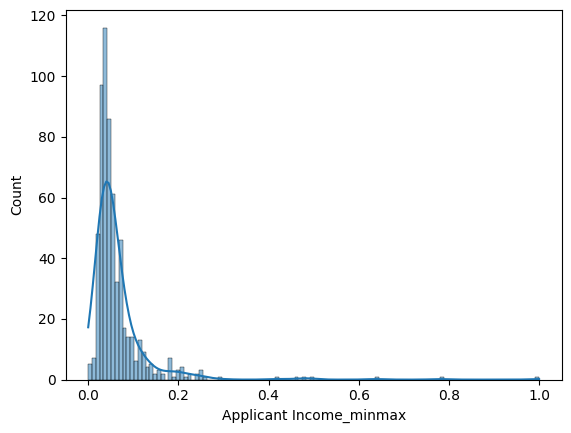

In [ ]:
#Scaling (Min-Max)
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Select numerical columns to scale (excluding categorical and Loan_ID)
numerical_cols = ['Applicant Income', 'Co applicant Income', 'Loan Amount', 'Loan_Amount_Term', 'Credit_History']
X = df[numerical_cols]

# Initialize MinMaxScaler
minmax_scaler = MinMaxScaler()
#Values close to 0 → Near the minimum observed value for that feature.
#Values close to 1 → Near the maximum observed value

# Fit and transform data
X_minmax = minmax_scaler.fit_transform(X)

# Convert back to DataFrame
df_minmax = pd.DataFrame(X_minmax, columns=[f"{col}_minmax" for col in numerical_cols])
print(df_minmax.head())

import seaborn as sns
sns.histplot(data=df_minmax, x="Applicant Income_minmax", kde=True)

In [ ]:
#Standarization (Z-score)
# Initialize StandardScaler
std_scaler = StandardScaler()

# Fit and transform data
X_std = std_scaler.fit_transform(X)
#±1: Within 68% of data (typical range).
#±2: Within 95% of data (uncommon but expected).
#±3: Beyond 99.7% of data (potential outliers).

# Convert back to DataFrame
df_std = pd.DataFrame(X_std, columns=[f"{col}_std" for col in numerical_cols])
print(df_std.head())

   Applicant Income_std  Co applicant Income_std  Loan Amount_std  \
0              0.605546                -0.555200        -0.155673   
1             -0.178931                -0.555200        -0.156067   
2             -0.202434                -0.058938        -0.155954   
3             -0.410674                -0.555200        -0.156304   
4             -0.440587                -0.555200        -0.156308   

   Loan_Amount_Term_std  Credit_History_std  
0              0.278582            0.433918  
1              0.278582                 NaN  
2              0.278582            0.433918  
3              0.278582            0.433918  
4              0.278582            0.433918  


In [ ]:
#Log transformation
# Apply log to positive numerical columns (add 1 to avoid log(0))
log_cols = ['Applicant Income', 'Co applicant Income', 'Loan Amount']
df_log = df[log_cols].apply(lambda x: np.log(x + 1))

# Rename columns
df_log.columns = [f"{col}_log" for col in log_cols]
print(df_log.head())

   Applicant Income_log  Co applicant Income_log  Loan Amount_log
0              9.114270                 0.000000         5.433722
1              8.368925                 0.000000         4.875197
2              8.335192                 7.277939         5.068904
3              7.972811                 0.000000         4.276666
4              7.908019                 0.000000         4.262680


In [ ]:
#Feature Engineering
import pandas as pd

#Measures the percentage of a borrower's income that goes toward debt repayment
df['Debt-to-Income Ratio'] = df['Loan Amount'] / df['Applicant Income']
print(df[['Applicant Income', 'Loan Amount', 'Debt-to-Income Ratio']])

     Applicant Income  Loan Amount  Debt-to-Income Ratio
0                9083        228.0              0.025102
1                4310        130.0              0.030162
2                4167        158.0              0.037917
3                2900         71.0              0.024483
4                2718         70.0              0.025754
..                ...          ...                   ...
614              5800        132.0              0.022759
615              3593        132.0              0.036738
616              3276        135.0              0.041209
617              1875         97.0              0.051733
618              9508        187.0              0.019668

[619 rows x 3 columns]


Correlation Matrix:
                      Applicant Income  Co applicant Income  Loan Amount  \
Applicant Income              1.000000            -0.117321    -0.051529   
Co applicant Income          -0.117321             1.000000     0.008606   
Loan Amount                  -0.051529             0.008606     1.000000   
Loan_Amount_Term             -0.043892            -0.063822     0.021186   
Credit_History               -0.013315            -0.007386     0.002742   
Debt-to-Income Ratio         -0.058894             0.005089     0.959616   

                      Loan_Amount_Term  Credit_History  Debt-to-Income Ratio  
Applicant Income             -0.043892       -0.013315             -0.058894  
Co applicant Income          -0.063822       -0.007386              0.005089  
Loan Amount                   0.021186        0.002742              0.959616  
Loan_Amount_Term              1.000000        0.012790              0.019917  
Credit_History                0.012790        1.0000

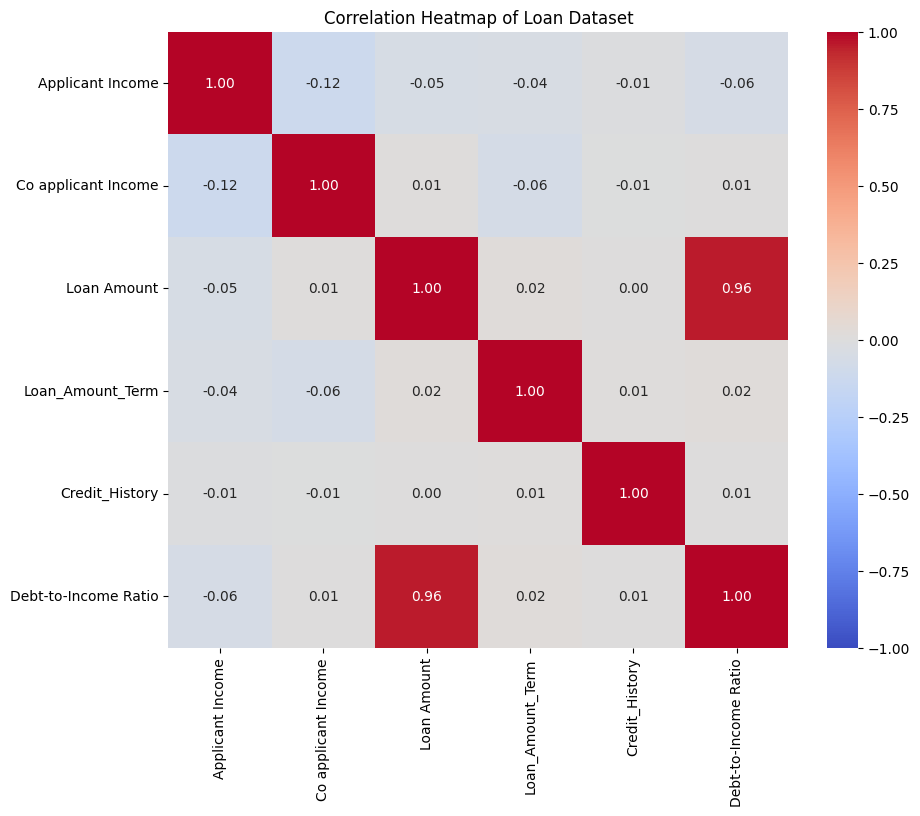

In [ ]:
#Draw a correlation/heatmap
#Select numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
corr_df = df[numerical_cols]

#generate correlation matrix
correlation_matrix = corr_df.corr()
print("Correlation Matrix:")
print(correlation_matrix)

#create heatmap visulization
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix,
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            center=0,
            vmin=-1,
            vmax=1)
plt.title("Correlation Heatmap of Loan Dataset")
plt.show()

#Strong Positive Correlations (≈ +1)
#Strong Negative Correlations (≈ -1)

Correlation Matrix:
                     Applicant Income  Co applicant Income  Loan Amount  \
Applicant Income             1.000000            -0.117321    -0.051529   
Co applicant Income         -0.117321             1.000000     0.008606   
Loan Amount                 -0.051529             0.008606     1.000000   
Loan_Amount_Term            -0.043892            -0.063822     0.021186   
Credit_History              -0.013315            -0.007386     0.002742   

                     Loan_Amount_Term  Credit_History  
Applicant Income            -0.043892       -0.013315  
Co applicant Income         -0.063822       -0.007386  
Loan Amount                  0.021186        0.002742  
Loan_Amount_Term             1.000000        0.012790  
Credit_History               0.012790        1.000000  


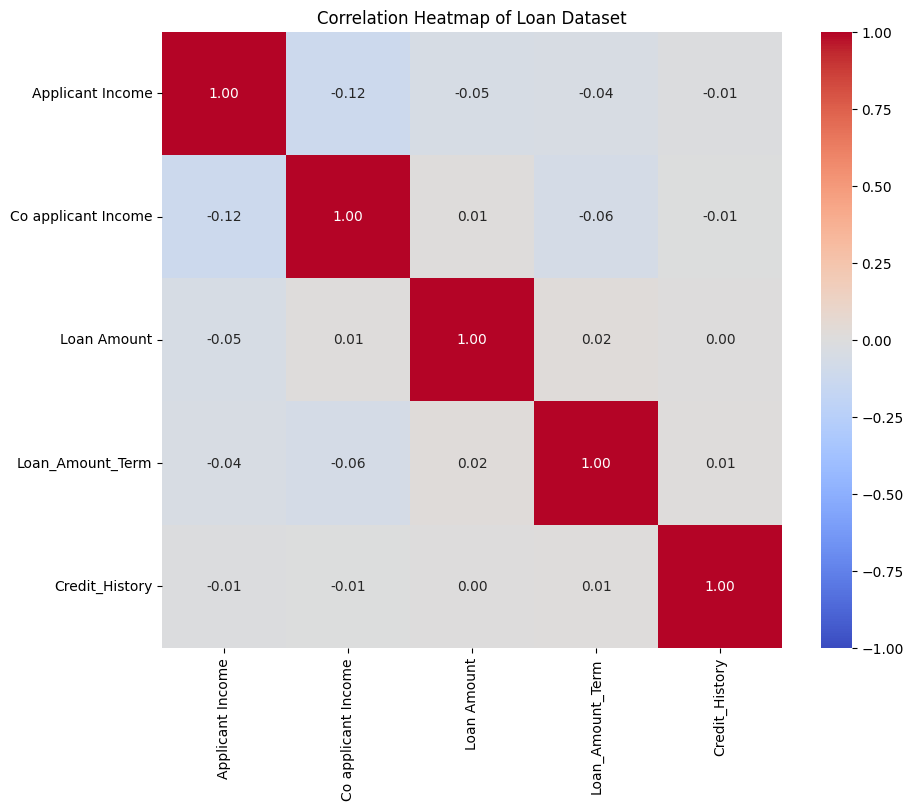

In [ ]:
#Draw a correlation/heatmap
#Select numerical columns
numerical_cols = df_encoded.select_dtypes(include=['int64', 'float64']).columns
corr_df = df_encoded[numerical_cols]

#generate correlation matrix
correlation_matrix = corr_df.corr()
print("Correlation Matrix:")
print(correlation_matrix)

#create heatmap visulization
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix,
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            center=0,
            vmin=-1,
            vmax=1)
plt.title("Correlation Heatmap of Loan Dataset")
plt.show()

#Strong Positive Correlations (≈ +1)
#Strong Negative Correlations (≈ -1)

In [ ]:
#Use the appropriate metric to calculate the correlation of: categorical features & numerical features
#To calculate the correlation between categorical and numerical features use ANOVA
#Use Case: Compare a numerical feature across categories (e.g., "Does Applicant Income differ by Education?")
from scipy.stats import f_oneway

# Example: Applicant Income across Education levels
groups = df.groupby('Education')['Applicant Income'].apply(list) #Groups the DataFrame df by the categorical column Education
#For each education level (e.g., "Graduate", "Not Graduate"), extracts the Applicant Income values as a list
f_stat, p_value = f_oneway(*groups)
print(f"F-statistic: {f_stat:.3f}, p-value: {p_value:.3f}")
#p-value: If p-value < 0.05, reject the null hypothesis

from scipy.stats import pointbiserialr

#Binary Categorical vs. Numerical
#How strongly is Loan_Status_Y (binary: 0/1) correlated with Applicant Income?
r_pb, p_value = pointbiserialr(df_encoded['Loan_Status_Y'], df['Applicant Income'])
#Computes the correlation between:
#df_encoded['Loan_Status_Y']: Binary target (0 = Rejected, 1 = Approved).
#df['Applicant Income']: Numerical feature

print(f"Point-Biserial r: {r_pb:.3f}, p-value: {p_value:.3f}")

F-statistic: 3.284, p-value: 0.011
Point-Biserial r: -0.004, p-value: 0.917


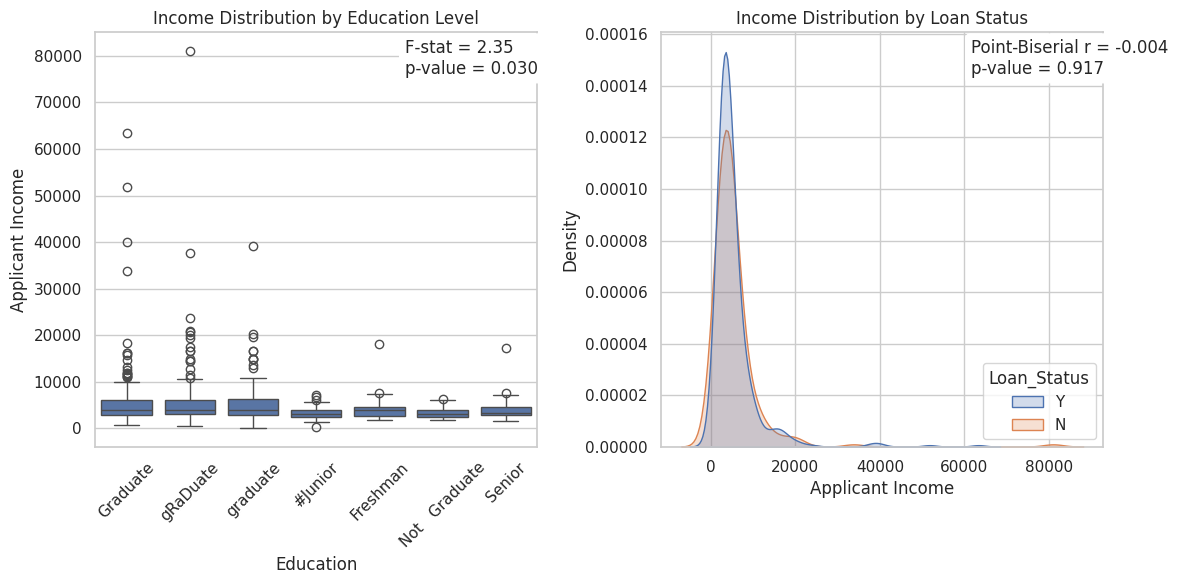


Statistical Results:
ANOVA - F-statistic: 2.353, p-value: 0.030
Point-Biserial r: -0.004, p-value: 0.917


In [ ]:
#visulatization of Use the appropriate metric to calculate the correlation of: categorical features & numerical features
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway, pointbiserialr

# Set style for plots
sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))

# ----------------------------------
# 1. ANOVA Visualization (Education vs. Applicant Income)
# ----------------------------------
plt.subplot(1, 2, 1)
sns.boxplot(x='Education', y='Applicant Income', data=df)
plt.title("Income Distribution by Education Level")
plt.xticks(rotation=45)

# Calculate ANOVA
groups = df.groupby('Education')['Applicant Income'].apply(list)
f_stat, p_value = f_oneway(*groups)
plt.annotate(f"F-stat = {f_stat:.2f}\np-value = {p_value:.3f}",
             xy=(0.7, 0.9), xycoords='axes fraction',
             bbox=dict(boxstyle='round', fc='white'))

# ----------------------------------
# 2. Point-Biserial Visualization (Loan Status vs. Income)
# ----------------------------------
plt.subplot(1, 2, 2)
sns.kdeplot(data=df, x='Applicant Income', hue='Loan_Status', fill=True, common_norm=False)
plt.title("Income Distribution by Loan Status")
plt.xlabel("Applicant Income")

# Calculate Point-Biserial Correlation
r_pb, pb_p_value = pointbiserialr(df_encoded['Loan_Status_Y'], df['Applicant Income'])
plt.annotate(f"Point-Biserial r = {r_pb:.3f}\np-value = {pb_p_value:.3f}",
             xy=(0.7, 0.9), xycoords='axes fraction',
             bbox=dict(boxstyle='round', fc='white'))

plt.tight_layout()
plt.show()

# Print statistical results
print("\nStatistical Results:")
print(f"ANOVA - F-statistic: {f_stat:.3f}, p-value: {p_value:.3f}")
print(f"Point-Biserial r: {r_pb:.3f}, p-value: {pb_p_value:.3f}")

In [ ]:
#Use the appropriate metric to calculate the correlation of: categorical features & categorical features
import numpy as np
from scipy.stats import chi2_contingency

def cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    return np.sqrt(phi2 / min((k-1), (r-1)))

# Example: Gender vs. Loan_Status
confusion_matrix = pd.crosstab(df['Gender'], df['Loan_Status'])
print(f"Cramer’s V: {cramers_v(confusion_matrix):.3f}")

Cramer’s V: 0.080


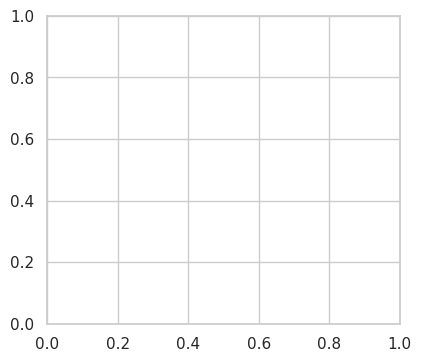

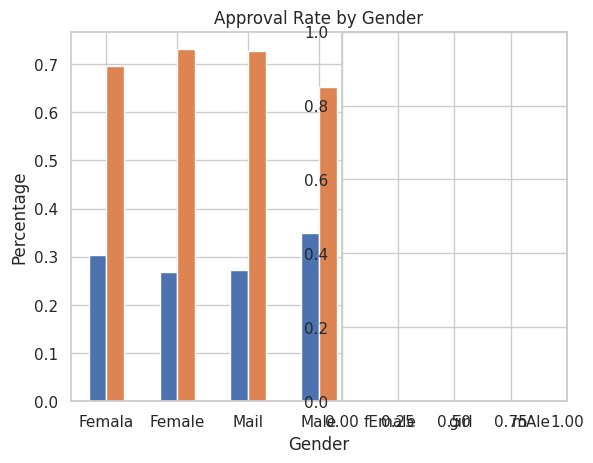

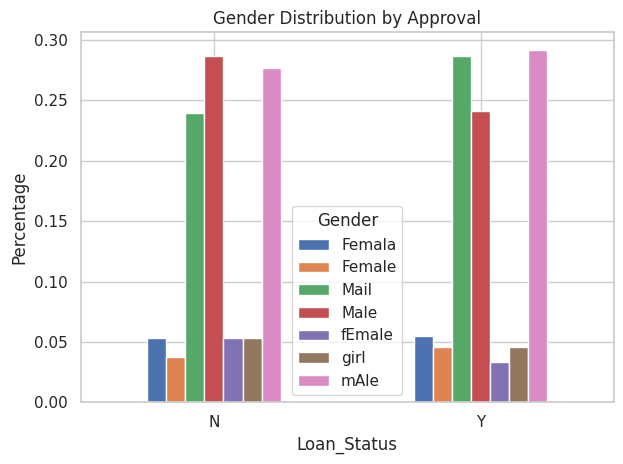

In [ ]:
#visulization for Use the appropriate metric to calculate the correlation of: categorical features & categorical features
import matplotlib.pyplot as plt

# Simple count plot
plt.figure(figsize=(10,4))

# Graph 1: Approval Rates by Gender
plt.subplot(1,2,1)
df.groupby('Gender')['Loan_Status'].value_counts(normalize=True).unstack().plot(kind='bar')
plt.title('Approval Rate by Gender')
plt.ylabel('Percentage')
plt.xticks(rotation=0)

# Graph 2: Gender Distribution by Loan Status
plt.subplot(1,2,2)
df.groupby('Loan_Status')['Gender'].value_counts(normalize=True).unstack().plot(kind='bar')
plt.title('Gender Distribution by Approval')
plt.ylabel('Percentage')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

Spearman Correlation Matrix:
                     Applicant Income  Co applicant Income  Loan Amount  \
Applicant Income             1.000000            -0.323132     0.472413   
Co applicant Income         -0.323132             1.000000     0.224161   
Loan Amount                  0.472413             0.224161     1.000000   
Loan_Amount_Term            -0.038851            -0.020556     0.053528   
Credit_History               0.044312            -0.014669     0.013305   

                     Loan_Amount_Term  Credit_History  
Applicant Income            -0.038851        0.044312  
Co applicant Income         -0.020556       -0.014669  
Loan Amount                  0.053528        0.013305  
Loan_Amount_Term             1.000000        0.026187  
Credit_History               0.026187        1.000000  


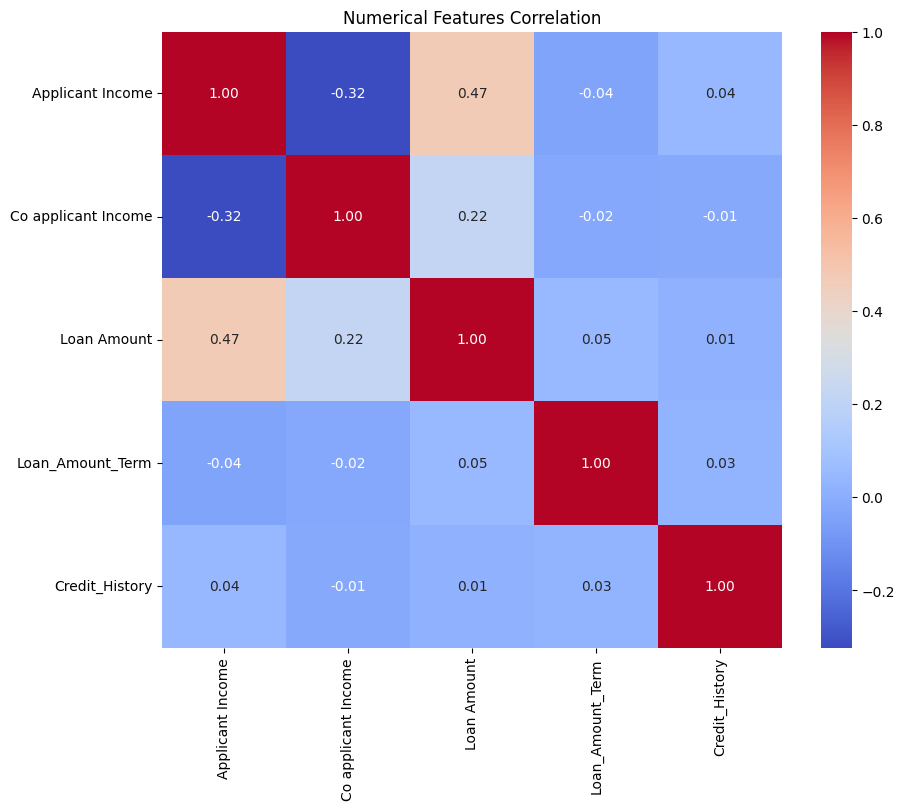

In [ ]:
#Use the appropriate metric to calculate the correlation of: numerical features & numerical features !!!!!!!!!!!!!!!!
#Pearson Correlation
import pandas as pd

# Select ONLY numerical columns (exclude strings/categories)
numerical_df = df.select_dtypes(include=['int64', 'float64'])

# Now calculate Spearman correlation
corr_matrix = numerical_df.corr(method='spearman')
print("Spearman Correlation Matrix:")
print(corr_matrix)

# Visualize
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Numerical Features Correlation")
plt.show()

In [ ]:
#Define Target and Features
y = df['Loan_Status'].map({'Y': 1, 'N': 0})  # Convert to binary (1/0)
# Select features
features = [
    'Applicant Income',
    'Co applicant Income',
    'Loan Amount',
    'Loan_Amount_Term',
    'Credit_History',
    'Gender',
    'Married',
    'Dependents',
    'Education',
    'Property_Area',
    'Self_Employed'
]
X = df[features]

# Encode categorical features
X = pd.get_dummies(X, columns=['Gender', 'Married', 'Education', 'Property_Area'])
print("Feature Matrix Shape:", X.shape)
print("Feature names:", X.columns.tolist())
#converts them to binary numbers

#Feature	What It Means	Example Rule
#Applicant Income	Higher income → More likely approve	"If income > $5,000 → +20% chance"
#Credit History	Good credit (1) → More likely	"If credit=1 → +40% chance"
#Loan Amount	Bigger loans → More scrutiny	"If loan > $300k → -15% chance"
#Education	Graduates → Slightly more likely	"If graduate → +5% chance"
#Property Area	Urban vs. rural differences	"If urban → +10% chance"

Feature Matrix Shape: (619, 26)
Feature names: ['Applicant Income', 'Co applicant Income', 'Loan Amount', 'Loan_Amount_Term', 'Credit_History', 'Dependents', 'Self_Employed', 'Gender_Femala', 'Gender_Female', 'Gender_Mail', 'Gender_Male', 'Gender_fEmale', 'Gender_girl', 'Gender_mAle', 'Married_No', 'Married_Yes', 'Education_#Junior', 'Education_Freshman', 'Education_Graduate', 'Education_Not   Graduate', 'Education_Senior', 'Education_gRaDuate', 'Education_graduate', 'Property_Area_Rural', 'Property_Area_Semiurban', 'Property_Area_Urban']


In [ ]:
#Split the Dataset
from sklearn.model_selection import train_test_split

# Split the data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Verify shapes
print("Training set shape:", X_train.shape, y_train.shape)
print("Testing set shape:", X_test.shape, y_test.shape)

Training set shape: (495, 26) (495,)
Testing set shape: (124, 26) (124,)


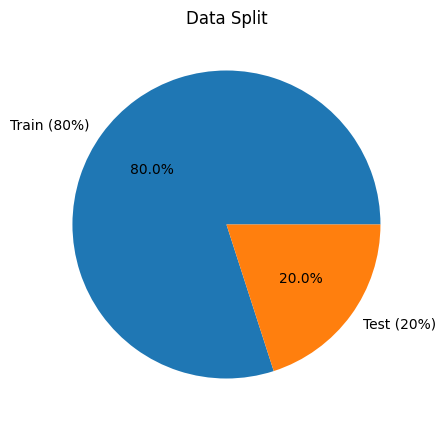

In [ ]:
import matplotlib.pyplot as plt

# Pie chart showing the split
plt.figure(figsize=(5,5))
plt.pie([len(X_train), len(X_test)],
        labels=['Train (80%)', 'Test (20%)'],
        autopct='%1.1f%%')
plt.title('Data Split')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report

# 1. Load and clean data
df = pd.read_excel('data.xlsx')

# 2. Safe conversion for 'Dependents'
with pd.option_context('future.no_silent_downcasting', True):
    df['Dependents'] = df['Dependents'].replace({'3+': '3'}).astype(float)

# 3. Define features and target
X = df.drop('Loan_Status', axis=1) #what columns we use to make the guess, which are all the columns but the Loan_Status column
y = df['Loan_Status'].map({'Y': 1, 'N': 0})  #what I'm trying to guess, which is the Loan_Status column itself

# 4. Auto-detect column types
numeric_cols = X.select_dtypes(include=np.number).columns.tolist() #Lists all number columns (e.g., income, loan amount)
categorical_cols = X.select_dtypes(exclude=np.number).columns.tolist() #categorical_cols: Lists all text/category columns (e.g., gender, education)

# 5. Create robust preprocessing pipeline
preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')), # Fills missing values with median
        ('scaler', StandardScaler()) # Normalizes data (mean=0, std=1)
    ]), numeric_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')), # Fills missing values with median
        ('encoder', OneHotEncoder(handle_unknown='ignore')) # Normalizes data (mean=0, std=1)
    ]), categorical_cols)
])

# 6. Full modeling pipeline
model = Pipeline([
    ('preprocessor', preprocessor), # First preprocess data
    ('classifier', LogisticRegression( # Then apply logistic regression #this is the actual machine learning algorithm #Analyzes all the applicant data (Income, Credit_History, etc.) #Calculates the probability of approval
        max_iter=1000, #Lets the model try up to 1,000 times to find the best pattern
        random_state=42, #Makes results reproducible #giving the same random questions every time
        class_weight='balanced' #Prevents ignoring rare rejections
    ))
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.59      0.68        39
           1       0.83      0.93      0.88        85

    accuracy                           0.82       124
   macro avg       0.81      0.76      0.78       124
weighted avg       0.82      0.82      0.81       124



Unsupervised Learning Explained (Simple Terms)
Unsupervised Learning is like giving a robot a pile of loan applications without telling it which were approved/rejected. The robot tries to:

Find hidden patterns (e.g., groups of similar applicants)

Detect weird applications (potential fraud)

Simplify complex data

In [ ]:
print(df[['Applicant Income', 'Loan Amount', 'Credit_History']].isna().sum())

Applicant Income     0
Loan Amount         21
Credit_History      51
dtype: int64


In [ ]:
Credit_History_median = df['Credit_History'].median()
df['Credit_History'].fillna(Credit_History_median, inplace=True)

/tmp/ipython-input-868417407.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Credit_History'].fillna(Credit_History_median, inplace=True)


In [ ]:
Loan_median = df['Loan Amount'].median()
df['Loan Amount'].fillna(Loan_median, inplace=True)

/tmp/ipython-input-3575703409.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Loan Amount'].fillna(Loan_median, inplace=True)


In [ ]:
print(df[['Applicant Income', 'Loan Amount', 'Credit_History']].isna().sum())

Applicant Income    0
Loan Amount         0
Credit_History      0
dtype: int64


In [ ]:
df['Applicant Income'] = df['Applicant Income'].astype('float64')

# Check the new data type of 'Applicant Income'
print("New data type of 'Applicant Income':", df['Applicant Income'].dtype)

# Display the DataFrame to see the change
print("\nDataFrame after conversion:")
print(df)

New data type of 'Applicant Income': float64

DataFrame after conversion:
      Loan_ID  Gender Married Dependents       Education Self_Employed  \
0    LP002139    mAle     Yes          0        Graduate            No   
1    LP002223    Mail     Yes          0        gRaDuate            No   
2    LP001570    mAle     Yes          2        graduate            No   
3    LP002978  Femala      No          0        gRaDuate            No   
4    LP001478    mAle      No          0        gRaDuate            No   
..        ...     ...     ...        ...             ...           ...   
614  LP002821    Male      No          0  Not   Graduate           Yes   
615  LP002789    Mail     Yes          0        graduate            No   
616  LP002272    Male     Yes          2        gRaDuate            No   
617  LP001245    mAle     Yes          2          Senior           Yes   
618  LP001935    mAle      No          0        graduate            No   

     Applicant Income  Co applicant I

In [ ]:
print(df[['Applicant Income', 'Loan Amount', 'Credit_History']].dtypes)

Applicant Income    float64
Loan Amount         float64
Credit_History      float64
dtype: object


In [ ]:
# Step 1: Create a new DataFrame with ONLY the columns used for clustering
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import pandas as pd

df_cluster = df[['Applicant Income', 'Loan Amount', 'Credit_History']].copy()

# Step 2: Scale and cluster
X_scaled = StandardScaler().fit_transform(df_cluster)
kmeans = KMeans(n_clusters=3, random_state=42)
df_cluster['Cluster'] = kmeans.fit_predict(X_scaled)

# Step 3: Calculate means (now safe)
print(df_cluster.groupby('Cluster').mean())

         Applicant Income   Loan Amount  Credit_History
Cluster                                                
0             4934.567839  1.434858e+02        0.855946
1             3268.533333  1.548821e+06        0.866667
2            49544.428571  3.831429e+02        0.714286


In [ ]:
# Assign risk labels
df['Risk_Level'] = df['Cluster'].map({
    0: 'Low Risk', #Moderate income, average loan amounts, and good credit history
    1: 'Fraud/Error', #Low income but extremely high loan amounts borrowed and decent credit history
    2: 'High-Income Conservative' #Very high income, larger but reasonable loan amounts, and slightly lower credit history
})

# Count applicants per risk level
print(df['Risk_Level'].value_counts())

#kmeans, elbow method

Risk_Level
Low Risk                    597
Fraud/Error                  15
High-Income Conservative      7
Name: count, dtype: int64


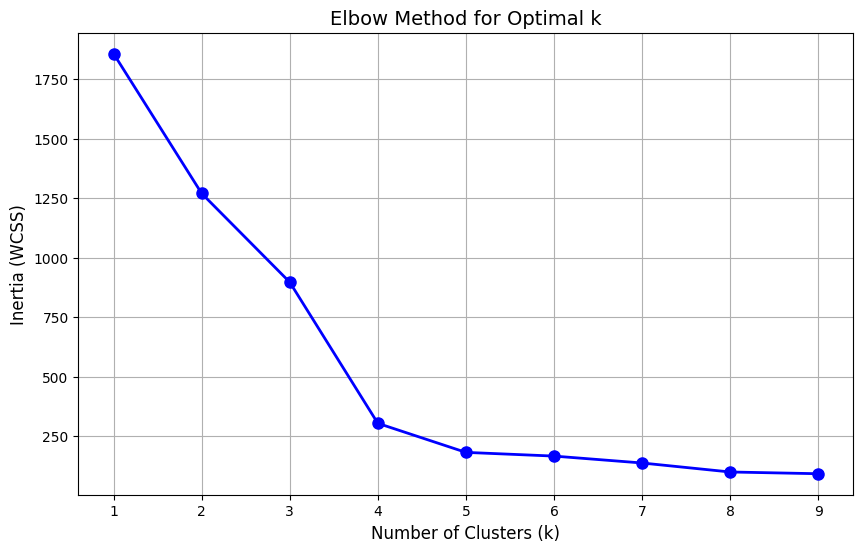

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# --- 1. Calculate inertia for k=1 to k=9 ---
inertia = []
for k in range(1, 10):  # Tests k from 1 to 9
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)  # Lower inertia = better

# --- 2. Plot the Elbow Curve ---
plt.figure(figsize=(10, 6))
plt.plot(range(1, 10), inertia, 'bo-', markersize=8, linewidth=2)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia (WCSS)', fontsize=12)
plt.title('Elbow Method for Optimal k', fontsize=14)
plt.xticks(range(1, 10))
plt.grid(True)
plt.show()